# Улучшение качества моделей: оптимизация гиперпараметров

## 1. Загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import (
    train_test_split, cross_validate, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from scipy.stats import loguniform, randint
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (11, 6)
sns.set_style('whitegrid')
RANDOM_STATE = 42

df = pd.read_csv('heart.csv')
print('Размер датасета:', df.shape)
df.head()

Размер датасета: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2]:
print('Пропуски по столбцам:', df.isnull().sum().sum())
df['HeartDisease'].value_counts()

Пропуски по столбцам: 0


HeartDisease
1    508
0    410
Name: count, dtype: int64

In [3]:
df.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

## 2. Подготовка данных: кодирование категориальных признаков

In [4]:
categorical = df.select_dtypes(include='object').columns.tolist()
print('Категориальные признаки:', categorical)
df_encoded = pd.get_dummies(df, columns=categorical, drop_first=True)
print('Размер после кодирования:', df_encoded.shape)
df_encoded.head()

Категориальные признаки: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Размер после кодирования: (918, 16)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


## 3. Разделение на обучающую и тестовую выборки (80/20)

In [5]:
X = df_encoded.drop(columns='HeartDisease')
y = df_encoded['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Обучающая выборка:', X_train.shape)
print('Тестовая выборка: ', X_test.shape)

Обучающая выборка: (734, 15)
Тестовая выборка:  (184, 15)


## 4. Базовая модель — логистическая регрессия (параметры по умолчанию)

In [6]:
baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])
baseline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Age','RestingBP','Cholesterol',...,'ExerciseAngina_Y','ST_Slope_Flat', 'ST_Slope_Up']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## 5. Метрики базовой модели (cross_validate, cv=10)

In [7]:
SCORING = ['accuracy', 'recall', 'precision', 'f1']

results = []

def cv_report(model, name):
    cv = cross_validate(model, X_train, y_train, cv=10, scoring=SCORING)
    row = {'модель': name}
    for m in SCORING:
        row[m] = round(cv['test_' + m].mean(), 4)
    results.append(row)
    print(f"{name:38s} | acc={row['accuracy']:.4f} recall={row['recall']:.4f} "
          f"precision={row['precision']:.4f} f1={row['f1']:.4f}")
    return row

cv_report(baseline, 'LogReg (по умолчанию)');

LogReg (по умолчанию)                  | acc=0.8472 recall=0.8718 precision=0.8562 f1=0.8631


**Базовая модель** даёт accuracy ≈ **0.85** и f1 ≈ **0.86** — уже неплохо. Recall (**0.87**) чуть выше precision — модель чаще «перестраховывается», что для медицинской задачи скорее плюс.

## 6. Оптимизация гиперпараметров

### 6a. GridSearchCV (логистическая регрессия)

In [8]:
param_grid = {
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear'],
    'clf__class_weight': [None, 'balanced'],
}

grid_search = GridSearchCV(
    baseline, param_grid, cv=10, scoring='f1', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print('Лучшие параметры (GridSearch):', grid_search.best_params_)
print('Лучший f1 на CV:', round(grid_search.best_score_, 4))

cv_report(grid_search.best_estimator_, 'LogReg (GridSearchCV)');

Лучшие параметры (GridSearch): {'clf__C': 0.01, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Лучший f1 на CV: 0.868
LogReg (GridSearchCV)                  | acc=0.8527 recall=0.8743 precision=0.8631 f1=0.8680


### 6b. RandomizedSearchCV (логистическая регрессия)

In [9]:
param_dist = {
    'clf__C': loguniform(1e-3, 1e2),
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear'],
    'clf__class_weight': [None, 'balanced'],
}

random_search = RandomizedSearchCV(
    baseline, param_dist, n_iter=30, cv=10, scoring='f1',
    random_state=RANDOM_STATE, n_jobs=-1
)
random_search.fit(X_train, y_train)

print('Лучшие параметры (RandomizedSearch):', random_search.best_params_)
print('Лучший f1 на CV:', round(random_search.best_score_, 4))

cv_report(random_search.best_estimator_, 'LogReg (RandomizedSearchCV)');

Лучшие параметры (RandomizedSearch): {'clf__C': np.float64(0.009962513222055111), 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Лучший f1 на CV: 0.868
LogReg (RandomizedSearchCV)            | acc=0.8527 recall=0.8743 precision=0.8631 f1=0.8680


Оба метода нашли практически одинаковый оптимум (`C≈0.01`, `penalty='l2'`).

### 6c. Несколько моделей классификации + подбор их параметров (RandomizedSearchCV)

In [10]:
rf_pipe = Pipeline([('clf', RandomForestClassifier(random_state=RANDOM_STATE))])
rf_dist = {
    'clf__n_estimators': randint(100, 400),
    'clf__max_depth': randint(3, 15),
    'clf__min_samples_split': randint(2, 10),
    'clf__max_features': ['sqrt', 'log2'],
}
rf_search = RandomizedSearchCV(rf_pipe, rf_dist, n_iter=25, cv=10, scoring='f1',
                               random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
print('RandomForest best:', rf_search.best_params_)
cv_report(rf_search.best_estimator_, 'RandomForest (RandomizedSearchCV)');

RandomForest best: {'clf__max_depth': 12, 'clf__max_features': 'log2', 'clf__min_samples_split': 7, 'clf__n_estimators': 290}
RandomForest (RandomizedSearchCV)      | acc=0.8677 recall=0.9063 precision=0.8642 f1=0.8836


In [11]:
svc_pipe = Pipeline([('scaler', StandardScaler()), ('clf', SVC())])
svc_dist = {
    'clf__C': loguniform(1e-2, 1e2),
    'clf__gamma': loguniform(1e-4, 1e0),
    'clf__kernel': ['rbf'],
}
svc_search = RandomizedSearchCV(svc_pipe, svc_dist, n_iter=25, cv=10, scoring='f1',
                                random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
print('SVM best:', svc_search.best_params_)
cv_report(svc_search.best_estimator_, 'SVM (RandomizedSearchCV)');

SVM best: {'clf__C': np.float64(0.6672367170464207), 'clf__gamma': np.float64(0.13826232179369857), 'clf__kernel': 'rbf'}
SVM (RandomizedSearchCV)               | acc=0.8596 recall=0.9039 precision=0.8528 f1=0.8771


In [12]:
gb_pipe = Pipeline([('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))])
gb_dist = {
    'clf__n_estimators': randint(100, 300),
    'clf__learning_rate': loguniform(1e-2, 3e-1),
    'clf__max_depth': randint(2, 6),
}
gb_search = RandomizedSearchCV(gb_pipe, gb_dist, n_iter=20, cv=10, scoring='f1',
                               random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
print('GradientBoosting best:', gb_search.best_params_)
cv_report(gb_search.best_estimator_, 'GradientBoosting (RandomizedSearchCV)');

GradientBoosting best: {'clf__learning_rate': np.float64(0.03574712922600244), 'clf__max_depth': 2, 'clf__n_estimators': 114}
GradientBoosting (RandomizedSearchCV)  | acc=0.8636 recall=0.9038 precision=0.8595 f1=0.8802


## 7. Выводы

### a) Сравнение метрик всех моделей

In [13]:
summary = pd.DataFrame(results)
summary = summary.sort_values('f1', ascending=False).reset_index(drop=True)
summary

,модель,accuracy,recall,precision,f1
0,RandomForest (RandomizedSearchCV),0.8677,0.9063,0.8642,0.8836
1,GradientBoosting (RandomizedSearchCV),0.8636,0.9038,0.8595,0.8802
2,SVM (RandomizedSearchCV),0.8596,0.9039,0.8528,0.8771
3,LogReg (GridSearchCV),0.8527,0.8743,0.8631,0.8680
4,LogReg (RandomizedSearchCV),0.8527,0.8743,0.8631,0.8680
5,LogReg (по умолчанию),0.8472,0.8718,0.8562,0.8631


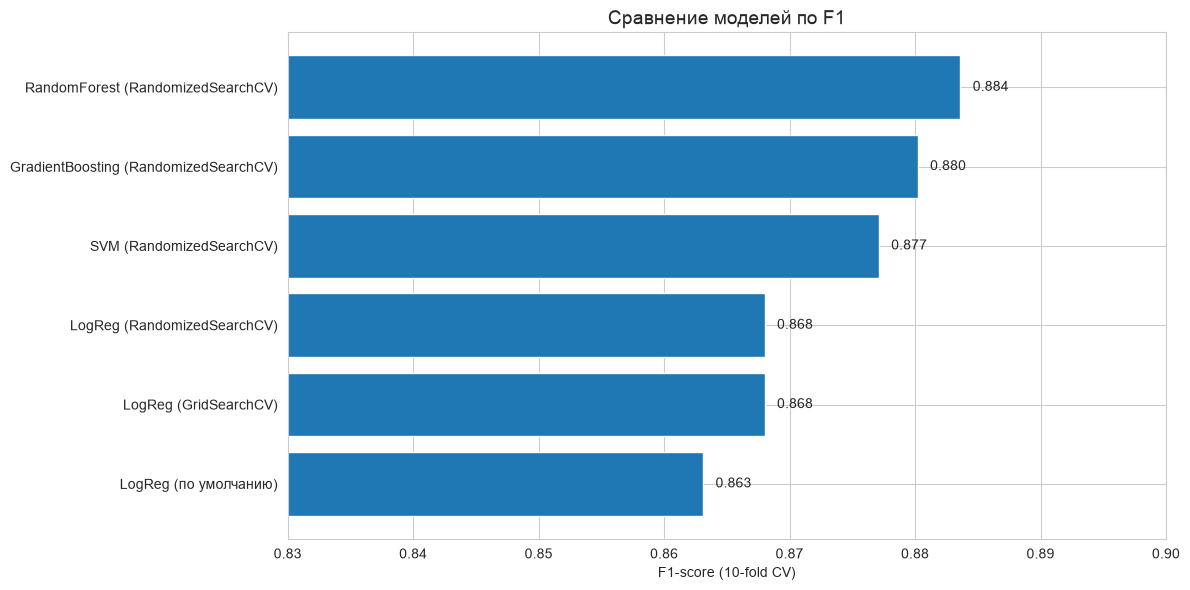

In [14]:
plt.figure(figsize=(12, 6))
order = summary.sort_values('f1')
bars = plt.barh(order['модель'], order['f1'], color='tab:blue', edgecolor='white')
plt.xlim(0.83, 0.90)
plt.xlabel('F1-score (10-fold CV)')
plt.title('Сравнение моделей по F1', fontsize=14)
for b, v in zip(bars, order['f1']):
    plt.text(v + 0.001, b.get_y() + b.get_height()/2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

In [15]:
test_rows = []
best_models = {
    'LogReg (GridSearchCV)': grid_search.best_estimator_,
    'RandomForest': rf_search.best_estimator_,
    'SVM': svc_search.best_estimator_,
    'GradientBoosting': gb_search.best_estimator_,
}
for name, est in best_models.items():
    est.fit(X_train, y_train)
    pred = est.predict(X_test)
    test_rows.append({
        'модель': name,
        'accuracy': round(accuracy_score(y_test, pred), 4),
        'recall': round(recall_score(y_test, pred), 4),
        'precision': round(precision_score(y_test, pred), 4),
        'f1': round(f1_score(y_test, pred), 4),
    })
pd.DataFrame(test_rows).sort_values('f1', ascending=False).reset_index(drop=True)

,модель,accuracy,recall,precision,f1
0,SVM,0.9022,0.9510,0.8818,0.9151
1,GradientBoosting,0.8967,0.9314,0.8879,0.9091
2,RandomForest,0.8859,0.9118,0.8857,0.8986
3,LogReg (GridSearchCV),0.8859,0.9020,0.8932,0.8976


### Выводы по проделанной работе

**a) Сравнение метрик построенных моделей**
1. **Оптимизация помогла.** Подбор гиперпараметров логистической регрессии поднял f1
   с **0.863 → 0.868**. `GridSearchCV` и `RandomizedSearchCV` дали почти идентичный
   результат: при небольшой сетке они сходятся к одному оптимуму, но `RandomizedSearchCV`
   эффективнее, когда параметров и их значений много.

2. **Смена модели дала больший прирост, чем тюнинг одной модели.** Ансамблевые методы
   (**RandomForest**, **GradientBoosting**) и **SVM** обошли логистическую регрессию.
   Лучшая по кросс-валидации — **RandomForest** (f1 ≈ **0.884**, recall ≈ **0.91**),
   что важно в медицине: высокий recall означает меньше пропущенных больных.

3. На отложенной тестовой выборке модели показывают f1 в районе **0.90–0.92**, что
   подтверждает устойчивость результата и отсутствие переобучения.

**b) Сравнение с домашним заданием «Ансамблирование»**

Результаты согласуются с выводами по ансамблям: там ансамблевые модели (случайный лес,
бустинг) также превосходили одиночную логистическую регрессию. Здесь мы это подтвердили
и уточнили: грамотный подбор гиперпараметров ансамблей через `RandomizedSearchCV`
даёт лучшее итоговое качество (f1 ≈ 0.88 на CV и ≈ 0.90+ на тесте). Таким образом,
максимальный эффект даёт сочетание выбора подходящего класса модели (ансамбли)
и автоматической оптимизации её гиперпараметров.